# Top Twitch Streamer Data EDA

Gaming is a very big industry now. Every year there are millions of dollars invested in Esports and many new companies want to invest in the Esports scene now. Twitch is a platform that facilitates this popularity through livestreaming and interacting with fans. It is one of, if not the biggest streaming platforms on the internet.  This dataset shows the Top 1000 streamers on Twitch. This dataset is a rather old dataset from roughly 6 years ago and not representative of the current landscape. However, it is a simple dataset that is easy to work with and good for beginners.

## Importing Data

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2

sns.set(style="whitegrid")
# Loading the data
data = pd.read_csv('twitchdata-update.csv')

In [28]:
print(data.info())
print(data.describe())
data.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Channel               1000 non-null   str  
 1   Watch time(Minutes)   1000 non-null   int64
 2   Stream time(minutes)  1000 non-null   int64
 3   Peak viewers          1000 non-null   int64
 4   Average viewers       1000 non-null   int64
 5   Followers             1000 non-null   int64
 6   Followers gained      1000 non-null   int64
 7   Views gained          1000 non-null   int64
 8   Partnered             1000 non-null   bool 
 9   Mature                1000 non-null   bool 
 10  Language              1000 non-null   str  
dtypes: bool(2), int64(7), str(2)
memory usage: 72.4 KB
None
       Watch time(Minutes)  Stream time(minutes)   Peak viewers  \
count         1.000000e+03           1000.000000    1000.000000   
mean          4.184279e+08         120515.160000   37065.051000   
std   

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
5,Asmongold,3668799075,82260,263720,42414,1563438,554201,61715781,True,False,English
6,NICKMERCS,3360675195,136275,115633,24181,4074287,1089824,46084211,True,False,English
7,Fextralife,3301867485,147885,68795,18985,508816,425468,670137548,True,False,English
8,loltyler1,2928356940,122490,89387,22381,3530767,951730,51349926,True,False,English
9,Anomaly,2865429915,92880,125408,12377,2607076,1532689,36350662,True,False,English


### Clean Data

In [29]:
data.isnull().sum()

Channel                 0
Watch time(Minutes)     0
Stream time(minutes)    0
Peak viewers            0
Average viewers         0
Followers               0
Followers gained        0
Views gained            0
Partnered               0
Mature                  0
Language                0
dtype: int64

### 1D Analysis

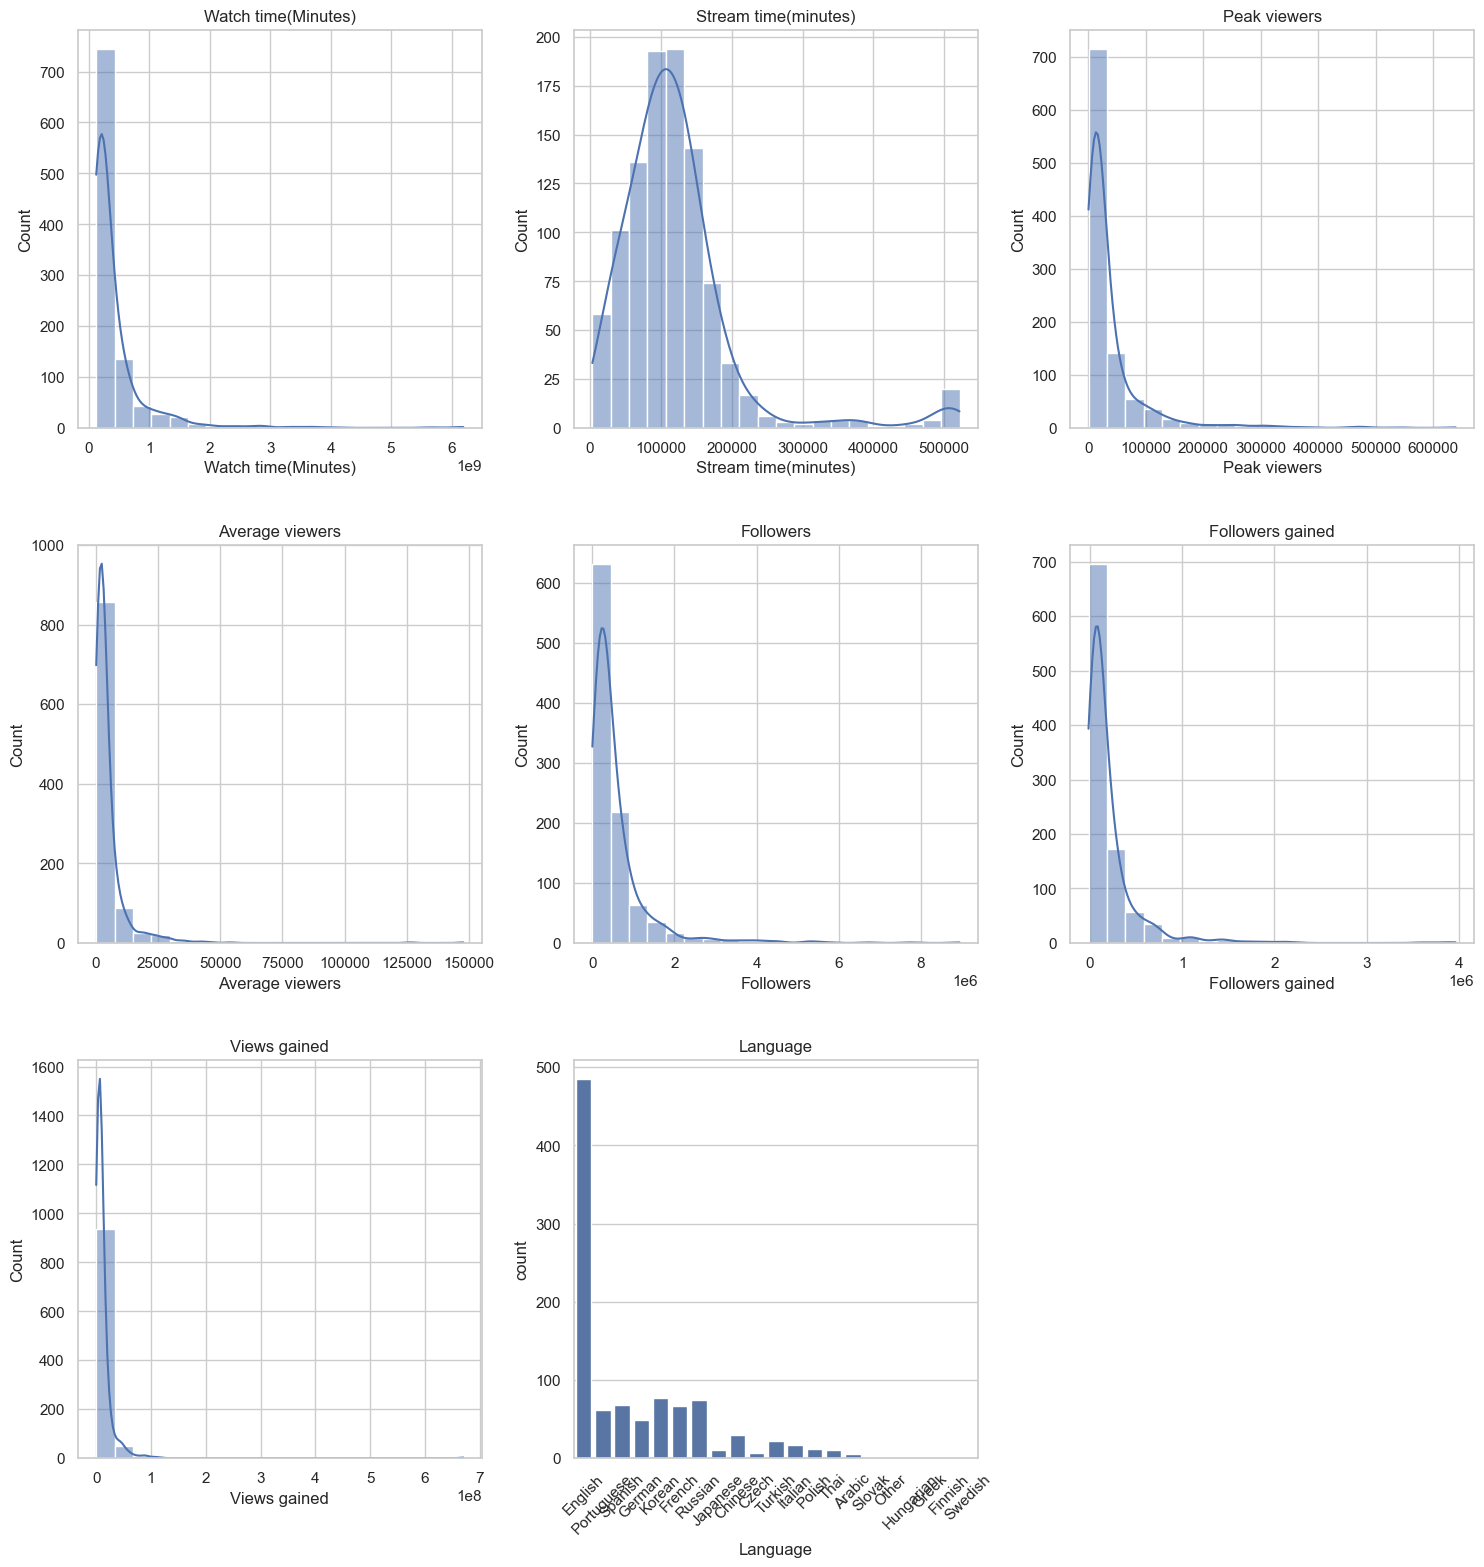

In [30]:
num_cols = data.select_dtypes(include='number').columns

cols = 3
rows = (len(data.columns) + cols - 1) // cols

total_plots = len(num_cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(col)

sns.countplot(x='Language', data=data, ax=axes[len(num_cols)])
axes[len(num_cols)].set_title("Language")
axes[len(num_cols)].tick_params(axis='x', rotation=45)

for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


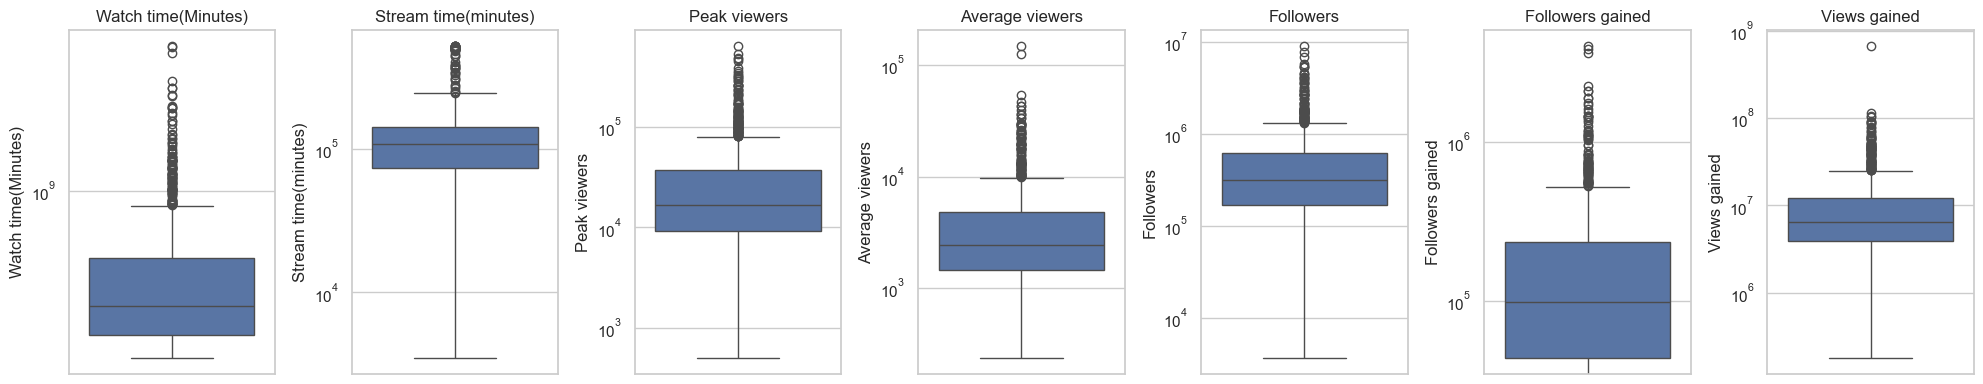

In [31]:
fig, axes = plt.subplots(1, 7, figsize=(20, 4)) 

for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_yscale('log')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [32]:
q1 = data[num_cols].quantile(0.25)
q3 = data[num_cols].quantile(0.75)
IQR = q3 - q1

outliers = ((data[num_cols] < (q1 - 1.5 * IQR)) | 
            (data[num_cols] > (q3 + 1.5 * IQR)))

print("Outliers per column:")
print(outliers.sum())

Outliers per column:
Watch time(Minutes)     107
Stream time(minutes)     48
Peak viewers            113
Average viewers         100
Followers                89
Followers gained         90
Views gained             91
dtype: int64


In [33]:
data.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Watch time(Minutes),1000.00,418427930.13,549635514.08,122192850.00,163189893.75,234990787.50,433739917.50,6196161750.00
Stream time(minutes),1000.00,120515.16,85376.20,3465.00,73758.75,108240.00,141843.75,521445.00
Peak viewers,1000.00,37065.05,60314.31,496.00,9113.75,16676.00,37569.75,639375.00
Average viewers,1000.00,4781.04,8453.68,235.00,1457.75,2425.00,4786.25,147643.00
Followers,1000.00,570054.07,804413.37,3660.00,170546.25,318063.00,624332.25,8938903.00
Followers gained,1000.00,205518.53,339913.71,-15772.00,43758.25,98352.00,236130.75,3966525.00
Views gained,1000.00,11668165.61,24905722.45,175788.00,3880602.50,6456323.50,12196762.00,670137548.00


From our graphs we can see that our mean is consistently being skewed by the max amounts. This is likely due to the fact that the top streamers get much more traction than the smaller streamers do even at the top 1000. The disparity between the top 1000 and the top 100 are very apparent to see through the standard deviation, which is consistently higher than the mean. The median, while offering better insights than the mean, still cannot tell the whole story. This is inherently a rather flawed dataset since it samples the top 1000 and is not representative of the average streamer. In order to make this dataset more reliable, it would be better to take random samples.

### 2D Analysis

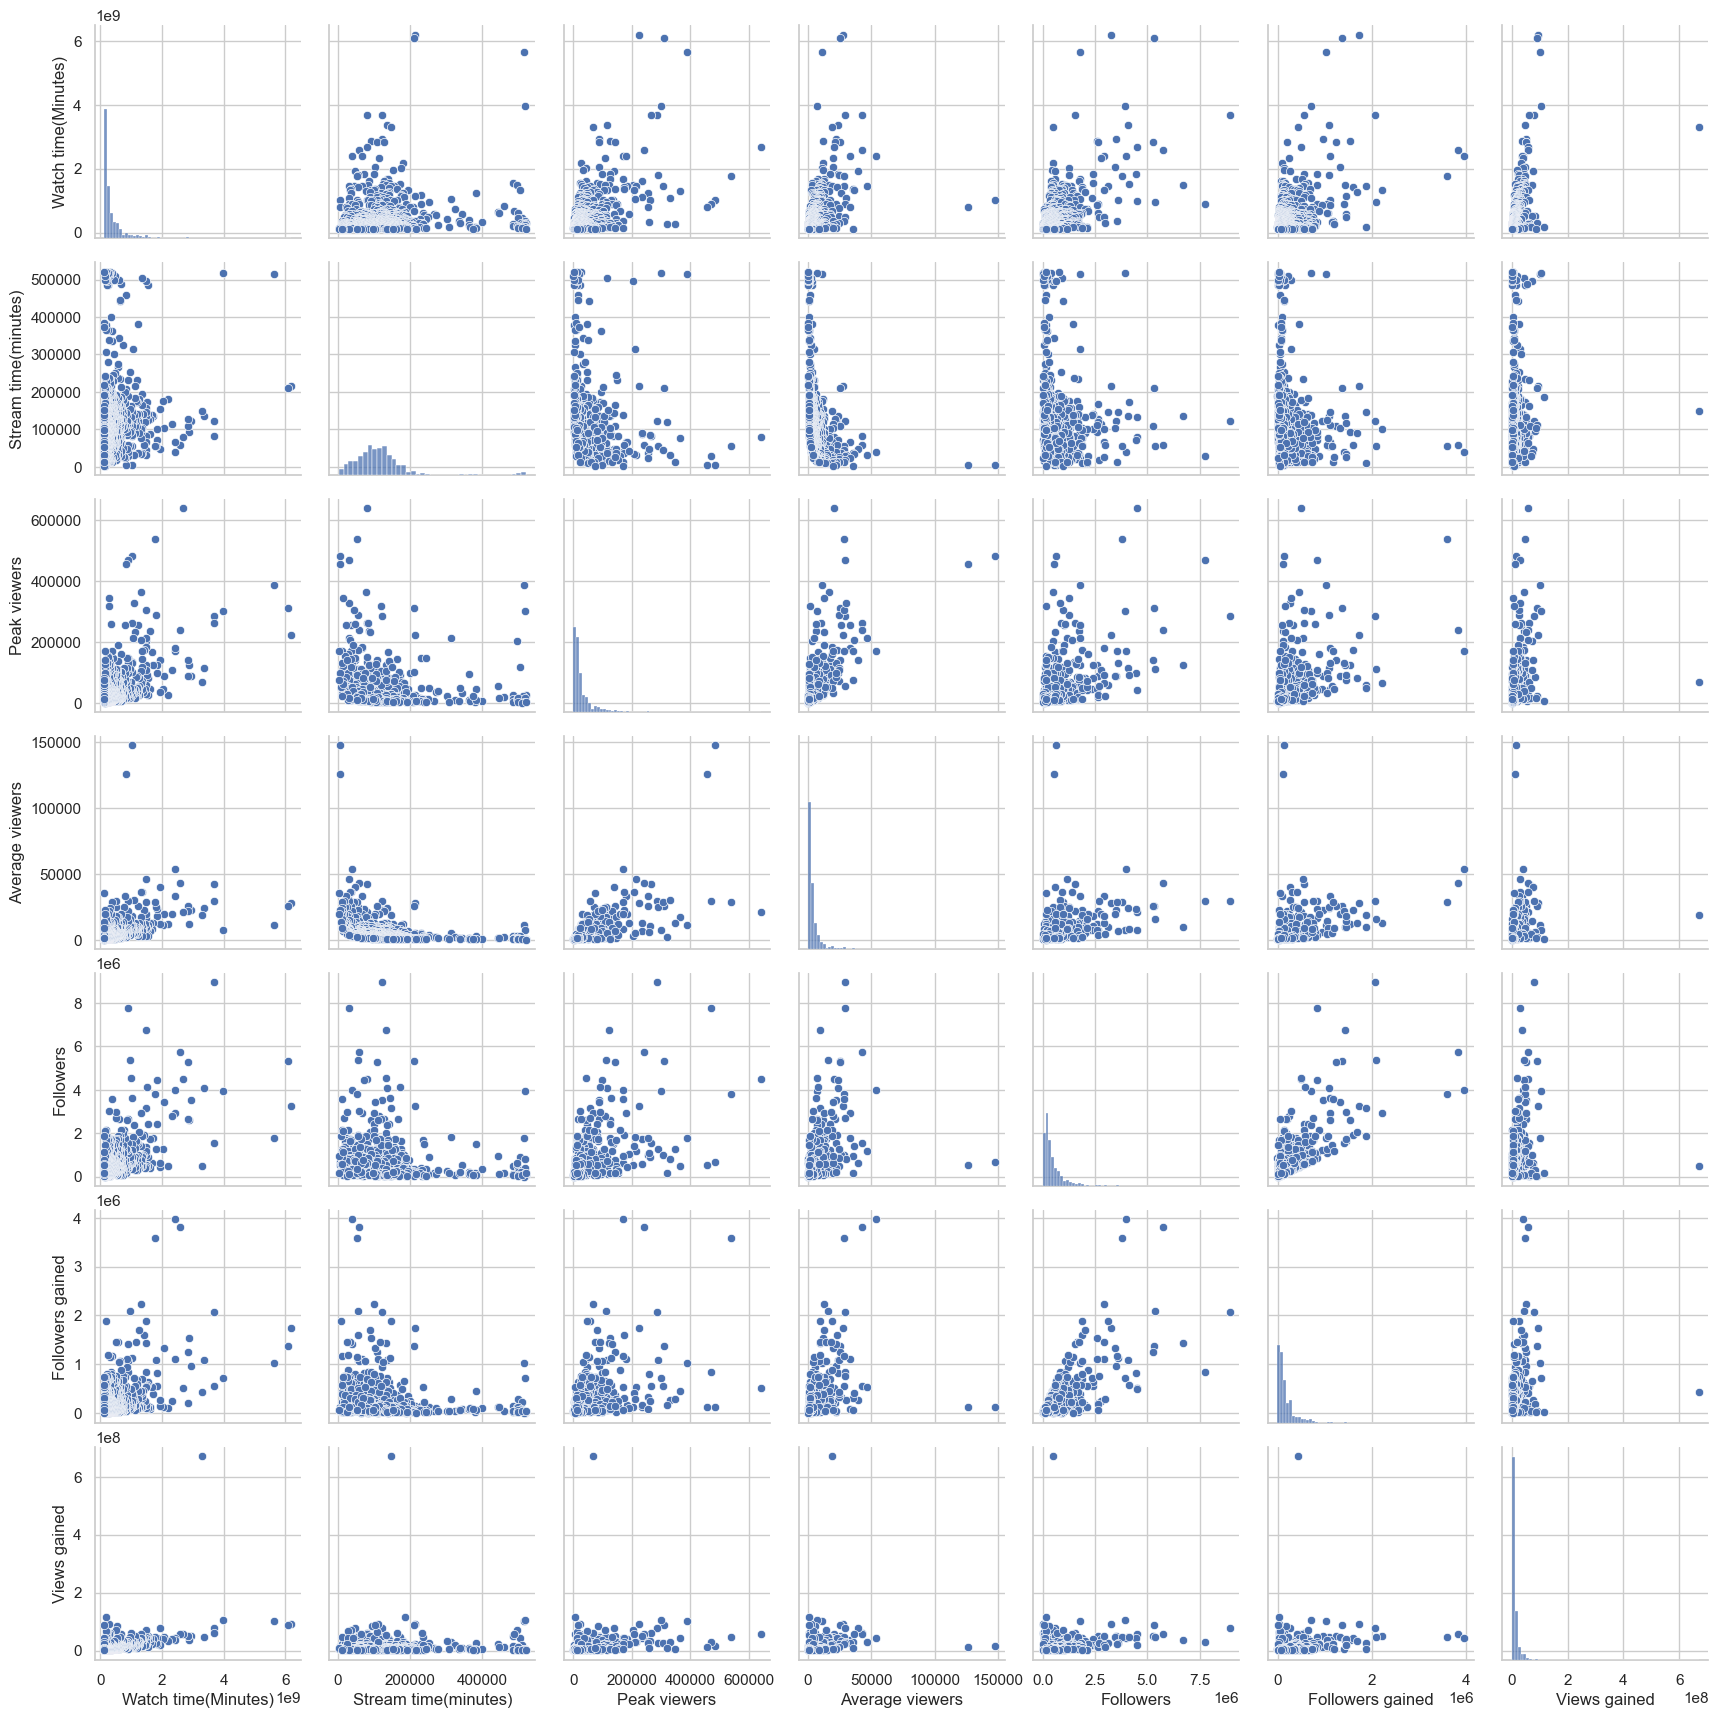

In [34]:
sns.pairplot(data[num_cols])
plt.show()

### Conclusions

* The dataset has a large amount of outliers
* There is a large disparity among the top 1000 and the top 100
* This is likely due to how popular streamers tend to remain popular and draw in other watchers from smaller streamers